In [86]:
import pandas as pd
import numpy as np
import time
import pickle 
#save and load models
import re  
#search and remove patterns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [87]:
fake_isot = pd.read_csv(r"C:\Users\wtpir\Documents\dataset\Fake.csv")
true_isot = pd.read_csv(r"C:\Users\wtpir\Documents\dataset\True.csv")
fake_isot['label'] = 0
true_isot['label'] = 1


def strip_reuters(text):
    text = str(text)
    match = re.search(r'\(Reuters\)*\)?\s*[-–]\s*', text[:300])
    if match:
        text = text[match.end():]
    text = re.sub(r'^[A-Za-z]+\s+\d+\s+\(Reuters\)\s*[-–]\s*', '', text)
    return text

true_isot['text'] = true_isot['text'].apply(strip_reuters)

# Combine and shuffle
df = pd.concat([fake_isot[['text','label']], true_isot[['text','label']]], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['text'] = df['text'].fillna('')
df['label'] = df['label'].astype(int)
df = df[df['text'].str.strip() != '']

print('Dataset size:', len(df))
print(df['label'].value_counts())

Dataset size: 44267
label
0    22851
1    21416
Name: count, dtype: int64


In [88]:
X = df['text']
y = df['label'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

print('Train:', len(X_train), '| Test:', len(X_test))

Train: 35413 | Test: 8854


In [89]:

vectorizer = TfidfVectorizer(
    max_features=50000, #most important words
    ngram_range=(1, 2), #Learn 
    stop_words='english', 
    max_df=0.85, #Ignore words 
    min_df=3, 
    
)

X_train_tfidf = vectorizer.fit_transform(X_train) 
X_test_tfidf = vectorizer.transform(X_test) 

print('Shape:', X_train_tfidf.shape)

Shape: (35413, 50000)


In [90]:


model = LogisticRegression(
    max_iter=1000, 
    C=1.0,  #prevents the model from memorizing
    solver='lbfgs', 
    n_jobs=-1,
    random_state=42, 
    class_weight='balanced'
)
model.fit(X_train_tfidf, y_train)
best_model = model



In [91]:

y_pred = best_model.predict(X_test_tfidf)

print('final accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

final accuracy: 0.9809125818838943
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4571
           1       0.98      0.98      0.98      4283

    accuracy                           0.98      8854
   macro avg       0.98      0.98      0.98      8854
weighted avg       0.98      0.98      0.98      8854



In [92]:
pickle.dump(best_model, open('best_fake_news_model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))
print('Model and vectorizer saved!')

Model and vectorizer saved!


In [93]:

def predict_news(text, confidence_threshold=0.40):
    try:
        global vectorizer, best_model
        if 'vectorizer' not in globals() or 'best_model' not in globals():
            vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
            best_model = pickle.load(open('best_fake_news_model.pkl', 'rb'))
    except FileNotFoundError:
        return 'Error'

    # Strip Reuters
    text = re.sub(r'^[A-Z\s,\.]+\(Reuters\)\s*[-\u2013]\s*', '', text)

    text_tfidf = vectorizer.transform([text])
    #Number of Non-Zero elements
    if text_tfidf.nnz == 0:
        return 'Uncertain '

    prob = best_model.predict_proba(text_tfidf)[0]
    pred = best_model.predict(text_tfidf)[0]
    confidence = prob[pred]

    if confidence < confidence_threshold:
        return f'Uncertain (Confidence: {confidence:.2f}) '

    return 'Real 🟢' if pred == 1 else 'Fake 🔴'


In [94]:
tests = [

    # ===== FAKE(20) =====
    "BREAKING: George Soros caught funding ISIS terrorists through secret Swiss bank accounts!! Pentagon has PROOF but deep state blocking arrest!!",
    "SHOCK: Hillary Clinton personally ordered the murder of four Americans in Benghazi!! Whistleblower has VIDEO EVIDENCE!! Share before deleted!!",
    "URGENT: Obama administration secretly imported 100,000 ISIS fighters into America disguised as refugees!! FBI has been ordered to stay SILENT!!",
    "BOMBSHELL: Donald Trump has been working as a Russian spy since 1987!! KGB documents LEAKED!! This is the biggest scandal in American history!!",
    "ALERT: The deep state just activated a plan to assassinate President Trump!! Three Secret Service agents have already been ARRESTED for treason!!",
    "CONFIRMED: Nancy Pelosi caught on hidden camera admitting Democrats stole the 2016 election!! Video being CENSORED by mainstream media!!",
    "EXPOSED: CIA secretly controls all major American newspapers and television networks!! Every news story you read is GOVERNMENT PROPAGANDA!!",
    "BREAKING: Scientists working on COVID vaccine found DEAD after discovering it causes permanent DNA damage!! Big Pharma COVERING IT UP!!",
    "SHOCK REPORT: Obama signed a secret executive order giving himself the power to remain president for life!! Hidden in page 2000 of legislation!!",
    "URGENT: Democrats passing secret legislation to ban the Bible and criminalize Christianity in America!! Mainstream media REFUSES to report this!!",
    "BOMBSHELL: Leaked NSA documents prove that every American smartphone has a secret government backdoor!! Your conversations are being RECORDED!!",
    "ALERT: United Nations troops secretly entering America through the southern border to prepare for martial law!! Patriots must RESIST!!",
    "BREAKING: Trump's doctor reveals he was poisoned by deep state operatives using a slow acting chemical!! Cover up at the highest levels!!",
    "EXPOSED: George W Bush and Dick Cheney personally planted explosives in the World Trade Center!! Confession LEAKED to underground journalist!!",
    "SHOCK: Planned Parenthood secretly selling baby body parts to Chinese biotech companies!! Congressional investigation being SUPPRESSED!!",
    "CONFIRMED: Facebook and Google working directly with the CIA to monitor every American citizen and flag political dissidents!!",
    "URGENT: New legislation will force all Americans to get a government implant or lose access to their bank accounts and healthcare!!",
    "BOMBSHELL: Democratic party officials running a massive money laundering operation through foreign charities!! IRS ordered to look the other way!!",
    "BREAKING: Vladimir Putin offered Obama 500 billion dollars to weaken the American military!! Secret recordings PROVE the deal was accepted!!",
    "ALERT: Scientists admit that chemotherapy was designed to make cancer patients sick so hospitals can charge more money!! Natural cures SUPPRESSED!!",

    # ===== REAL (20) =====
    "President Trump signed an executive order directing federal agencies to reduce regulations, saying the move would boost economic growth and job creation.",
    "The Senate voted along party lines to confirm the president's Supreme Court nominee after Democrats attempted to block the confirmation with a filibuster.",
    "White House officials confirmed the president would travel to Asia next month for meetings with leaders of Japan, South Korea, China and the Philippines.",
    "The Trump administration moved to roll back Obama-era environmental regulations, directing the EPA to begin the process of repealing the clean power plan.",
    "Congressional investigators requested documents from the Treasury Department as part of a broad investigation into Russian interference in the 2016 election.",
    "The president met with Republican congressional leaders at the White House to discuss the timeline for passing tax reform legislation before the end of the year.",
    "Federal authorities arrested a man in New York who they say was planning an attack inspired by the Islamic State on the city's subway system.",
    "The administration announced it would impose additional sanctions on North Korea following the country's latest ballistic missile test over Japan.",
    "Republican and Democratic lawmakers reached a deal to fund the government for two years, setting aside a standoff over immigration and spending limits.",
    "The White House announced the resignation of chief of staff Reince Priebus, naming General John Kelly as his replacement effective immediately.",
    "A federal grand jury indicted former Trump campaign chairman Paul Manafort on charges of money laundering and failing to register as a foreign agent.",
    "The president delivered his first address to a joint session of Congress, calling for unity and outlining his priorities on immigration, trade and infrastructure.",
    "Secretary of Defense James Mattis visited troops stationed in Afghanistan and reaffirmed the United States commitment to supporting the Afghan government.",
    "The administration proposed sweeping changes to the legal immigration system, prioritizing skills based admissions over family reunification policies.",
    "Senate majority leader Mitch McConnell announced the chamber would vote on a healthcare bill to repeal and replace the Affordable Care Act next week.",
    "The president signed an executive order temporarily banning refugees and travelers from several majority Muslim countries from entering the United States.",
    "Federal investigators examining Russian interference in the 2016 election interviewed several current and former White House officials this week.",
    "The administration announced plans to renegotiate the North American Free Trade Agreement with Canada and Mexico to better protect American workers.",
    "House Republicans passed a budget resolution that would allow them to pass tax reform legislation with a simple majority vote in the Senate.",
    "The president nominated retired General John Kelly to serve as secretary of homeland security, pending confirmation by the United States Senate.",

]

correct = 0
for i, t in enumerate(tests):
    result = predict_news(t)
    expected = 'Fake 🔴' if i < 20 else 'Real 🟢'
    status = '✅' if expected in result else '❌'
    print(f'{status} {result} | {t[:80]}...')
    if expected in result:
        correct += 1

print(f'\nScore: {correct}/{len(tests)} correct')

✅ Fake 🔴 | BREAKING: George Soros caught funding ISIS terrorists through secret Swiss bank ...
✅ Fake 🔴 | SHOCK: Hillary Clinton personally ordered the murder of four Americans in Bengha...
✅ Fake 🔴 | URGENT: Obama administration secretly imported 100,000 ISIS fighters into Americ...
✅ Fake 🔴 | BOMBSHELL: Donald Trump has been working as a Russian spy since 1987!! KGB docum...
✅ Fake 🔴 | ALERT: The deep state just activated a plan to assassinate President Trump!! Thr...
✅ Fake 🔴 | CONFIRMED: Nancy Pelosi caught on hidden camera admitting Democrats stole the 20...
✅ Fake 🔴 | EXPOSED: CIA secretly controls all major American newspapers and television netw...
✅ Fake 🔴 | BREAKING: Scientists working on COVID vaccine found DEAD after discovering it ca...
✅ Fake 🔴 | SHOCK REPORT: Obama signed a secret executive order giving himself the power to ...
✅ Fake 🔴 | URGENT: Democrats passing secret legislation to ban the Bible and criminalize Ch...
✅ Fake 🔴 | BOMBSHELL: Leaked NSA documents prove t

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

y_pred = best_model.predict(X_test_tfidf)
y_prob = best_model.predict_proba(X_test_tfidf)[:, 1] 



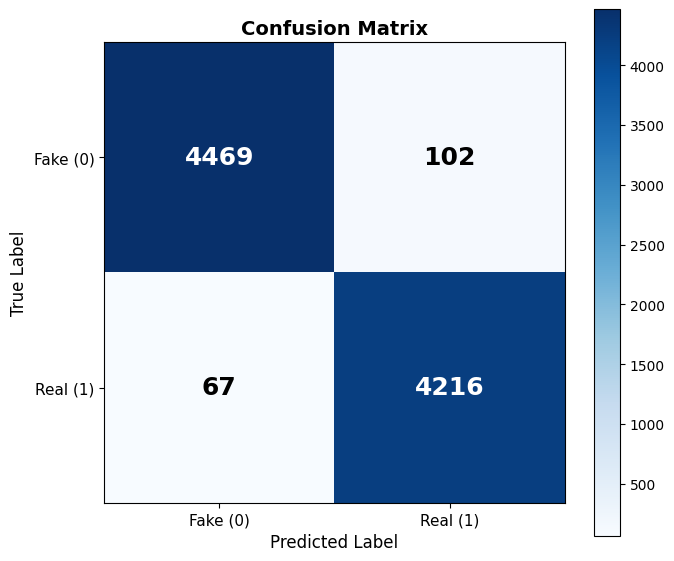

In [96]:

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Fake (0)', 'Real (1)'], fontsize=11)
ax.set_yticklabels(['Fake (0)', 'Real (1)'], fontsize=11)
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()



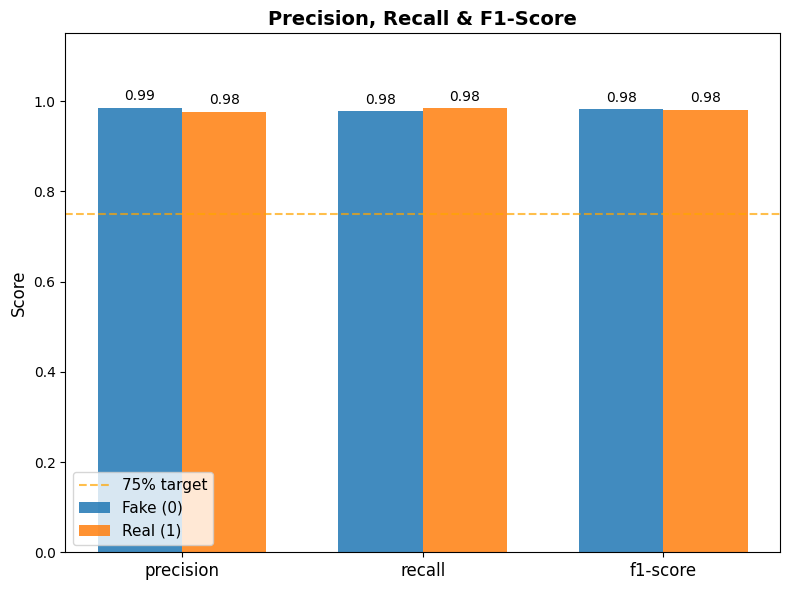

In [97]:
report = classification_report(y_test, y_pred, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
fake_scores = [report['0'][m] for m in metrics]
real_scores = [report['1'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, fake_scores, width, label='Fake (0)', alpha=0.85)
bars2 = ax.bar(x + width/2, real_scores, width, label='Real (1)', alpha=0.85)

ax.set_title('Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.axhline(y=0.75, color='orange', linestyle='--', alpha=0.7, label='75% target')
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

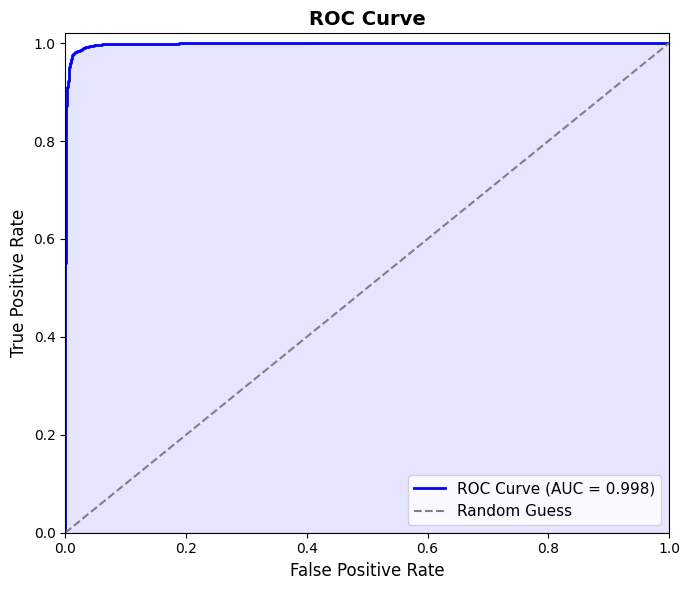

AUC Score: 0.9981
AUC = 1.0 → Perfect model
AUC = 0.5 → Random guessing


In [98]:
# AUC - ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="blue", lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess')
ax.fill_between(fpr, tpr, alpha=0.1, color='blue')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f'AUC Score: {roc_auc:.4f}')
print('AUC = 1.0 → Perfect model')
print('AUC = 0.5 → Random guessing')

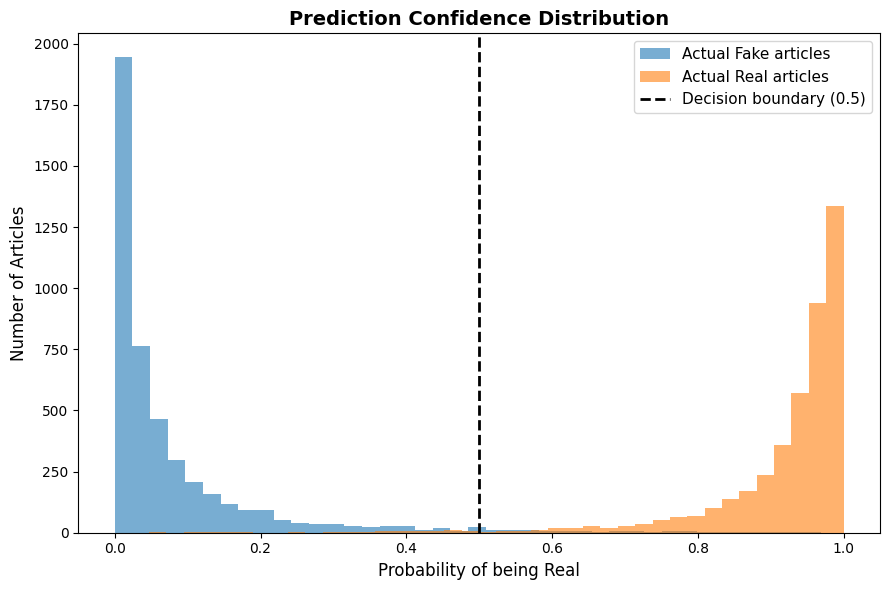

In [99]:
#Prediction Confidence Distribution
fig, ax = plt.subplots(figsize=(9, 6))

fake_probs = y_prob[y_test == 0]  
real_probs = y_prob[y_test == 1]  

ax.hist(fake_probs, bins=40, alpha=0.6, label='Actual Fake articles')
ax.hist(real_probs, bins=40, alpha=0.6, label='Actual Real articles')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary (0.5)')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Probability of being Real', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

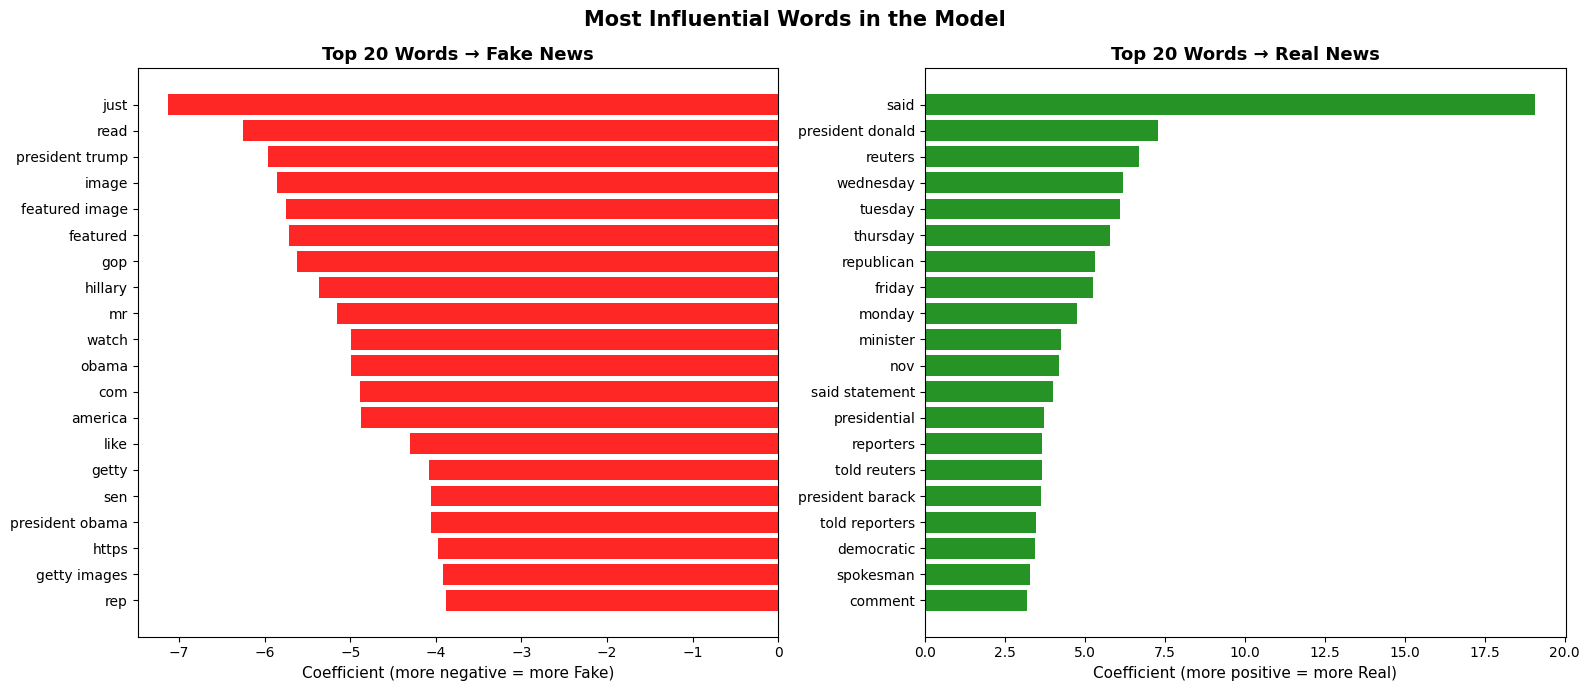

In [100]:

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients  = best_model.coef_[0]

top_fake_idx = np.argsort(coefficients)[:20]     
top_real_idx = np.argsort(coefficients)[-20:][::-1] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Fake words
ax1.barh(feature_names[top_fake_idx], coefficients[top_fake_idx], color="red", alpha=0.85)
ax1.set_title('Top 20 Words → Fake News', fontsize=13, fontweight='bold')
ax1.set_xlabel('Coefficient (more negative = more Fake)', fontsize=11)
ax1.invert_yaxis()

# Real words
ax2.barh(feature_names[top_real_idx], coefficients[top_real_idx], color='green', alpha=0.85)
ax2.set_title('Top 20 Words → Real News', fontsize=13, fontweight='bold')
ax2.set_xlabel('Coefficient (more positive = more Real)', fontsize=11)
ax2.invert_yaxis()

plt.suptitle('Most Influential Words in the Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [101]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = auc(*roc_curve(y_test, y_prob)[:2])

print('       MODEL PERFORMANCE SUMMARY')
print(f'  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision  : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall     : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score   : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  AUC Score  : {roc_auc:.4f}')
print(f'  Total test articles : {len(y_test)}')
print(f'  Correctly predicted : {(y_pred == y_test).sum()}')
print(f'  Wrongly predicted   : {(y_pred != y_test).sum()}')


       MODEL PERFORMANCE SUMMARY
  Accuracy   : 0.9809  (98.09%)
  Precision  : 0.9809  (98.09%)
  Recall     : 0.9809  (98.09%)
  F1-Score   : 0.9809  (98.09%)
  AUC Score  : 0.9981
  Total test articles : 8854
  Correctly predicted : 8685
  Wrongly predicted   : 169
